# How new concepts spread: diffusion types, community roles, timing (RQ2) — demo

This notebook is a runnable walk-through of the **RQ2 diffusion experiment** on emerging scientific concepts from an
OpenAlex-based co-word / concept–subfield knowledge network (yearly snapshots 2000–2024).

The original artifact is driven by `method.py`, a small orchestrator that runs 13 stages (`src/*.py`) in order:
`prep → attach → indicators → labels → leiden_seeds → typology → roles → leadlag → patterns → validation → cases → method_out → freeze`.
Most stages need the full iteration-2 snapshot graphs (GBs of parquet) and cannot run in Colab. The key result of the
experiment, the **data-derived diffusion typology**, needs only the per-concept, per-year indicator table built by the
`indicators` stage. This notebook therefore:

1. shows the `method.py` orchestrator unchanged (stage order and runner),
2. loads a curated subset (`mini_demo_data.json`: 100 of the 202 screen-MAIN concepts with their yearly indicators),
3. runs the **`typology` stage** (`src/typology.py`) and the vendored helpers it imports (`analysis_patterns._cluster / _stability / _series_tensor`),
   copied with minimal changes:
   * a **3-channel** trajectory per concept: rarefied Shannon entropy over subfields `H_rar`, Rao–Stirling diversity `RS`, active subfields in a 3-year window,
   * a length-normalised **multivariate DTW** distance (Sakoe–Chiba radius 3) + **k-medoids** (FasterPAM),
   * **k selection by Hennig bootstrap Jaccard stability** (every cluster's mean Jaccard > 0.75),
   * baselines: **B1** entropy-only typology (the iteration-2 recipe) and **B2** volume (terciles and a volume-series DTW clustering),
   * a volume-residualised variant, sensitivity analyses, rule-based cluster naming, and permutation chi-square cross-tabs.

On the full 202 concepts, only k = 2 was stable (min Jaccard 0.861): **"localised"** (n = 136) vs
**"broad from the start"** (n = 66). The clustering was not volume-driven (AMI with volume terciles 0.014).
The last cell compares the demo run with these full-run numbers.

## 1. Install dependencies
`tslearn` (DTW) and `kmedoids` (FasterPAM) are not pre-installed on Colab. They are installed with `--no-deps` so they
cannot upgrade Colab's numpy, scipy or scikit-learn. The core scientific stack is installed only outside Colab, at Colab's exact versions.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# tslearn, kmedoids, loguru — NOT on Colab, always install (no-deps so Colab's numpy/scipy/sklearn stay untouched;\n# tslearn 0.7.0 instead of the original 0.9.0, whose numba kernels do not compile with Colab's numba 0.60)
_pip('--no-deps', 'tslearn==0.7.0', 'kmedoids==0.5.5')
_pip('loguru==0.7.3')

# numpy, pandas, scikit-learn, scipy, matplotlib, numba — pre-installed on Colab, install locally only (Colab versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0',
         'numba==0.60.0', 'joblib')

## 2. Imports
First the original import block of `method.py`, then the one of `src/typology.py`, then `common.py`'s `wilson` interval
and `json`/`Path` (used to write the stage outputs) plus `matplotlib` for the final figure.

In [2]:
# ---- method.py (orchestrator)
from __future__ import annotations

import argparse
import os
import subprocess
import sys
import time
from pathlib import Path

# ---- src/typology.py
import math

import numpy as np
import pandas as pd
from loguru import logger
from scipy.stats import spearmanr
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score

# ---- extra for the notebook
import json
import matplotlib.pyplot as plt
import kmedoids
from tslearn.metrics import dtw_path, cdist_dtw

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## 3. Load the demo data
`mini_demo_data.json` is loaded from GitHub, with a fallback to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-3/experiment-8/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("examples:", len(data["examples"]), "| series columns:", data["series_columns"])

Curated subset of the RQ2 diffusion-typology experiment: 100 of the 202 screen-MAIN emerging concepts (stratified by full-run 3-channel cluster; the 2 frozen medoids are always included). Each example carries the yearly concept-level indicators (2000-2024) needed to rebuild the 3-channel series (rarefied Shannon H_rar, Rao-Stirling RS, active subfields in 3-yr window), the entropy-only baseline series H, and volume.
examples: 100 | series columns: ['year', 'age', 'vol', 'vol3', 'H', 'H_rar', 'RS', 'RS_rar', 'richness_rar', 'active_subfields_3y']


## 4. Configuration
Every tunable parameter is set here. The values below are the ones this notebook was tested with. The original
full-run values are in the comments: the full run used all 202 screen-MAIN concepts, while this demo file holds 100 of them.

In [5]:
N_CONCEPTS = 100          # concepts taken from mini_demo_data.json (max 100 here; original: 202 screen-MAIN concepts)
K_RANGE = list(range(2, 9))  # candidate numbers of clusters (original: range(2, 9))
B_BOOT = 200              # bootstrap replicates for Hennig Jaccard stability (original: 200)
B_BOOT_SENS = 100         # bootstrap replicates for secondary variants / sensitivities (original: 100)
N_PERM = 10000            # permutations for the cross-tab chi-square tests (original: 10000)
N_PERM_EXPL = 2000        # permutations for exploratory finer-k cross-tab (original: 2000)
JAC_MIN = 0.75            # Hennig 'stable' threshold on every cluster's mean Jaccard (original: 0.75)
DTW_RADIUS = 3            # Sakoe-Chiba radius for the 3-channel DTW (original: 3)

## 5. The original orchestrator (`method.py`)
These are the stage order and the stage runner from `method.py`, unchanged. Each stage is a separate `src/<stage>.py`
script run as a subprocess. **This cell is not executed here** because the other stages need the full snapshot data. It
only defines the orchestrator so that you can see how the pipeline is wired. The rest of the notebook runs the `typology` stage inline.

In [6]:
ROOT = Path(".").resolve()   # method.py: Path(__file__).resolve().parent
ORDER = ["prep", "attach", "indicators", "labels", "leiden_seeds", "typology", "roles", "leadlag", "patterns", "validation",
         "cases", "method_out", "freeze"]


def run(stage: str, env: dict | None = None) -> float:
    t0 = time.time()
    r = subprocess.run([sys.executable, str(ROOT / "src" / f"{stage}.py")], cwd=ROOT / "src", env=env or os.environ.copy())
    if r.returncode != 0:
        raise SystemExit(f"stage {stage} failed (exit {r.returncode})")
    return time.time() - t0


def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--stage", nargs="*", default=None)
    ap.add_argument("--mini", action="store_true")
    a = ap.parse_args()
    if a.mini:
        mini()
        return
    for st in a.stage or ORDER:
        secs = run(st)
        print(f"stage {st} done in {secs:.0f}s", flush=True)

# Not called in the notebook (needs src/*.py and the iteration-2 snapshots). Stage that this notebook runs inline:
print("pipeline:", " -> ".join(ORDER), "\nrunning inline: typology")

pipeline: prep -> attach -> indicators -> labels -> leiden_seeds -> typology -> roles -> leadlag -> patterns -> validation -> cases -> method_out -> freeze 
running inline: typology


## 6. Rebuild the stage inputs from the demo data
The `typology` stage reads two files: `results/indicators/concept_year_indicators_hyd.parquet` (one row per concept and
year) and `work/pool_active.parquet` (one row per concept, with fold, arm, population flags and origin field).
It also reads `results/labels/groups.csv`, which holds the RQ1 emergence label `E_up` and the closure tercile. Here the three
tables are rebuilt from `data`. Outputs go to a local `demo_outputs/` folder (the originals were `typology/` and `results/`).
The held-out concepts are sealed and not included in the data, so `load_sealed()` / `assert_not_sealed()` are not needed.

In [7]:
ex = data["examples"][:N_CONCEPTS]
rows = []
for e in ex:
    s = e["series"]
    for i in range(len(s["year"])):
        rows.append(dict(concept_id=e["concept_id"], F=e["F"], fold=e["fold"], **{c: s[c][i] for c in data["series_columns"]}))
ind = pd.DataFrame(rows)
for c in data["series_columns"]:
    ind[c] = pd.to_numeric(ind[c], errors="coerce").astype(float)
ind["year"] = ind.year.astype(int)
pool = pd.DataFrame([{k: v for k, v in e.items() if k != "series"} for e in ex])
grp = pool.set_index("concept_id")[["E_up_group", "closure_tercile"]].rename(columns={"E_up_group": "group"})

TYP = RES = Path("demo_outputs")
TYP.mkdir(exist_ok=True)
C_SPEC_TYPOLOGY = dict(ages=list(range(0, 9)), max_missing=3, max_fill=2)   # vendor/config.py SPEC["typology"] (used by B1)

CH = ["H_rar", "RS", "active_subfields_3y"]
CH_RAR = ["H_rar", "RS_rar", "richness_rar"]
print(ind.shape, "concept-years;", pool.shape[0], "concepts")
pool[["concept_id", "phrase", "F", "origin_group", "route", "E_up_group", "full_run_cluster_name"]].head(8)

(1627, 13) concept-years; 100 concepts


,concept_id,phrase,F,origin_group,route,E_up_group,full_run_cluster_name
0,c_007a7950eb4d,dantzig selector,2007,F26:Mathematics,B_s2_index,emerging,broad from the start (rapid interdisciplinary)
1,c_029ea7c780b8,deep convolutional feature,2016,F17:Computer Science,B_s2_index,censored,broad from the start (rapid interdisciplinary)
2,c_03828aedf823,emergent gravity,2006,F31:Physics and Astronomy,B_s2_index,emerging,broad from the start (rapid interdisciplinary)
3,c_1055d445e4c2,holographic qcd,2006,F31:Physics and Astronomy,B_s2_index,emerging,localised
4,c_108519c4a344,generalized proca,2016,F31:Physics and Astronomy,B_s2_index,censored,broad from the start (rapid interdisciplinary)
5,c_11a854e37d5c,weyl semimetal nbp,2016,F31:Physics and Astronomy,B_s2_index,censored,localised
6,c_1273a1959f6d,inflationary magnetogenesis,2012,F31:Physics and Astronomy,B_s2_index,never,localised
7,c_133dd7d5dfff,deep hashing,2015,F17:Computer Science,B_s2_index,censored,localised


## 7. Helper functions from `common.py` and the vendored `analysis_patterns.py`
`wilson` is the Wilson score interval from `common.py`. `_series_tensor`, `_cluster` and `_stability` come from the vendored
iteration-2 `analysis_patterns.py`:

* `_cluster` runs FasterPAM k-medoids on a precomputed distance matrix.
* `_stability` implements **Hennig's (2007) bootstrap Jaccard**. It resamples the concepts, re-clusters them, and records,
  for each original cluster, the best Jaccard overlap with any bootstrap cluster. It returns the mean over replicates.
* `_series_tensor` builds the entropy-only B1 input: `H` at ages 0–8, z-scored, with short gaps filled.

In [8]:
def wilson(k: int, n: int, z: float = 1.959964) -> tuple[float, float]:
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (c - h, c + h)


def _series_tensor(ind: pd.DataFrame, channels: list[str]) -> tuple[np.ndarray, list[str], int]:
    T = C_SPEC_TYPOLOGY   # original: S["typology"]
    scr = ind[(ind.fold == "screen")].copy()
    for ch in channels:
        v = scr[ch].astype(float)
        scr[ch] = (v - v.mean()) / v.std()
    ages = T["ages"]
    X, ids, dropped = [], [], 0
    for c, g in scr.groupby("concept_id"):
        g = g.set_index("age").reindex(ages)[channels]
        missing = g.isna().any(axis=1).sum()
        if missing > T["max_missing"]:
            dropped += 1
            continue
        g = g.ffill(limit=T["max_fill"]).bfill(limit=T["max_fill"]).fillna(0.0)
        X.append(g.values)
        ids.append(c)
    return np.array(X), ids, dropped


def _cluster(D: np.ndarray, k: int, seed: int = 0) -> np.ndarray:
    import kmedoids
    # .astype(np.int64): kmedoids returns uint64 labels, which numpy 2.0 (Colab) refuses to np.bincount
    return np.asarray(kmedoids.fasterpam(D, k, random_state=seed).labels).astype(np.int64)


def _stability(D: np.ndarray, labels: np.ndarray, k: int, B: int, seed: int = 0) -> list[float]:
    rng = np.random.default_rng(seed)
    n = len(D)
    jac = np.zeros((B, k))
    for b in range(B):
        idx = np.unique(rng.integers(0, n, n))
        if len(idx) <= k:
            continue
        lb = _cluster(D[np.ix_(idx, idx)], k, seed=b)
        for ci in range(k):
            A = set(idx[labels[idx] == ci])
            best = 0.0
            for cb in range(k):
                Bs = set(idx[lb == cb])
                u = len(A | Bs)
                if u:
                    best = max(best, len(A & Bs) / u)
            jac[b, ci] = best
    return jac.mean(axis=0).tolist()

## 8. Typology functions (`src/typology.py`, unchanged)
* `build_series` builds each concept's raw multichannel series for years F..2024, where F is the concept's first-use year.
  It applies the declared missing-value rule: a missing `H_rar` falls back to raw `H`, and any other missing value becomes 0.
  It also records the share of imputed concept-years.
* `zscale` z-scores each channel over all concept-years. `dtw_norm` / `dist_matrix` compute the multivariate DTW
  (Sakoe–Chiba band) divided by √(path length), so concepts of different ages are comparable.
* `select_k` clusters for every k and scores each k by min bootstrap Jaccard and silhouette. It picks the largest stable k
  (ties inside a 0.02 Jaccard band go to the higher silhouette).
* `entropy_only` is baseline B1. `perm_chi2` is a permutation chi-square with Cramér's V and standardised residuals.
* `describe` / `name_clusters` name clusters **after** clustering, using a declared rule on the median breadth trajectory.

In [9]:
# ----------------------------------------------------------------------------- series
def build_series(ind: pd.DataFrame, ids: list[str], channels: list[str], ages: list[int] | None = None,
                 impute: bool = True) -> tuple[dict, pd.DataFrame]:
    """Per-concept raw (unscaled) multichannel series and the per-concept imputed share.

    Declared missing rule: H_rar NaN (vol3 < 10) -> raw H of the same window (imputed); if vol3 == 0 -> H = RS = 0 and
    count = 0 (imputed if the value was NaN); any other NaN (e.g. all window papers without a known subfield) -> 0
    (imputed). No concept is excluded.
    """
    ser, imp = {}, []
    sub = ind[ind.concept_id.isin(set(ids))]
    for c, g in sub.groupby("concept_id"):
        F = int(g.F.iloc[0])
        g = g[(g.year >= F) & (g.year <= 2024)].sort_values("year")
        if ages is not None:
            g = g[g.age.isin(ages)]
        X = np.zeros((len(g), len(channels)))
        n_imp = np.zeros(len(g), dtype=bool)
        for j, ch in enumerate(channels):
            v = g[ch].astype(float).values.copy()
            if ch == "H_rar":
                fb = np.isnan(v)
                v[fb] = g.H.astype(float).values[fb]
                n_imp |= fb
            nan = np.isnan(v)
            n_imp |= nan
            v[nan] = 0.0
            X[:, j] = v
        ser[c] = X
        imp.append(dict(concept_id=c, n_years=len(g), imputed_share=float(n_imp.mean()) if len(g) else np.nan))
    return ser, pd.DataFrame(imp)


def zscale(ser: dict) -> tuple[dict, dict]:
    allv = np.vstack(list(ser.values()))
    mu, sd = allv.mean(axis=0), allv.std(axis=0)
    sd[sd == 0] = 1.0
    return {c: (X - mu) / sd for c, X in ser.items()}, dict(mean=mu.tolist(), sd=sd.tolist())


def dtw_norm(a: np.ndarray, b: np.ndarray, radius: int = DTW_RADIUS, normalise: bool = True) -> float:
    from tslearn.metrics import dtw_path
    path, d = dtw_path(a, b, global_constraint="sakoe_chiba", sakoe_chiba_radius=radius)
    return float(d / math.sqrt(len(path))) if normalise else float(d)


def dist_matrix(ser: dict, ids: list[str], radius: int = DTW_RADIUS, normalise: bool = True) -> np.ndarray:
    n = len(ids)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            D[i, j] = D[j, i] = dtw_norm(ser[ids[i]], ser[ids[j]], radius, normalise)
    return D


# ----------------------------------------------------------------------------- clustering
def select_k(D: np.ndarray, k_range=K_RANGE, B: int = B_BOOT) -> dict:
    import kmedoids
    res = {}
    for k in k_range:
        if k >= len(D):
            continue
        lb = _cluster(D, k)
        st = _stability(D, lb, k, B, seed=k)
        sil = float(silhouette_score(D, lb, metric="precomputed")) if len(set(lb)) > 1 else np.nan
        med = kmedoids.fasterpam(D, k, random_state=0).medoids
        res[k] = dict(labels=lb, jaccard=st, min_jaccard=float(min(st)), silhouette=sil,
                      sizes=np.bincount(lb, minlength=k).tolist(), medoids=[int(m) for m in med])
    stable = [k for k in res if res[k]["min_jaccard"] > JAC_MIN]
    if stable:
        top = max(stable)
        # tie-break: among stable k in the same min-Jaccard band (within 0.02 of each other) prefer higher silhouette
        band = [k for k in stable if abs(res[k]["min_jaccard"] - res[top]["min_jaccard"]) < 0.02 and k >= top - 1]
        k_sel = max(band, key=lambda k: (res[k]["silhouette"], k))
        status = "stable"
    else:
        k_sel = max(res, key=lambda k: (res[k]["min_jaccard"], res[k]["silhouette"]))
        status = "no stable typology"
    return dict(by_k=res, k_sel=k_sel, status=status, stable_ks=stable)


def hennig_band(j: float) -> str:
    return "stable" if j > 0.75 else ("pattern" if j >= 0.6 else ("weak" if j > 0.5 else "dissolved"))


def ami(a: pd.Series, b: pd.Series) -> float:
    m = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
    return float(adjusted_mutual_info_score(m.a.astype(str), m.b.astype(str))) if len(m) > 5 else np.nan


# ----------------------------------------------------------------------------- baselines
def entropy_only(ind: pd.DataFrame, ids: list[str], k: int | None, B: int = B_BOOT, seed: int = 99) -> dict:
    """B1: the iteration-2 entropy-only recipe (analysis_patterns._series_tensor on raw H, ages 0..8, z-scored over the
    given screen concepts, cdist_dtw radius 2, fasterpam). k=None -> k selected by the same stability rule."""
    from tslearn.metrics import cdist_dtw
    sub = ind[ind.concept_id.isin(set(ids))].copy()
    sub["fold"] = "screen"
    X, idh, dropped = _series_tensor(sub, ["H"])
    Dh = cdist_dtw(X, global_constraint="sakoe_chiba", sakoe_chiba_radius=2)
    if k is None:
        sel = select_k(Dh, B=B)
        k = sel["k_sel"]
        lb = sel["by_k"][k]["labels"]
        st = sel["by_k"][k]["jaccard"]
        table = {str(kk): dict(min_jaccard=v["min_jaccard"], jaccard=v["jaccard"], silhouette=v["silhouette"], sizes=v["sizes"])
                 for kk, v in sel["by_k"].items()}
        status = sel["status"]
    else:
        lb = _cluster(Dh, k)
        st = _stability(Dh, lb, k, B, seed=seed)
        table, status = None, None
    return dict(ids=idh, labels=np.asarray(lb), k=k, jaccard=st, min_jaccard=float(min(st)), n=len(idh),
                n_dropped_missing=dropped, table=table, status=status, D=Dh)


def perm_chi2(a: pd.Series, b: pd.Series, n_perm: int = N_PERM, seed: int = 0) -> dict:
    m = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
    ai = pd.factorize(m.a.astype(str), sort=True)
    bi = pd.factorize(m.b.astype(str), sort=True)
    ka, kb, n = len(ai[1]), len(bi[1]), len(m)
    if ka < 2 or kb < 2:
        return dict(n=n, chi2=np.nan, p_perm=np.nan)

    def chi2(x, y):
        tab = np.bincount(x * kb + y, minlength=ka * kb).reshape(ka, kb).astype(float)
        e = tab.sum(1, keepdims=True) * tab.sum(0, keepdims=True) / n
        return float(((tab - e) ** 2 / np.where(e > 0, e, 1)).sum()), tab, e

    obs, tab, e = chi2(ai[0], bi[0])
    rng = np.random.default_rng(seed)
    ge = 0
    for _ in range(n_perm):
        if chi2(ai[0], rng.permutation(bi[0]))[0] >= obs - 1e-12:
            ge += 1
    rs = (tab - e) / np.sqrt(np.where(e > 0, e, 1) * (1 - tab.sum(1, keepdims=True) / n) * (1 - tab.sum(0, keepdims=True) / n))
    V = math.sqrt(obs / (n * (min(ka, kb) - 1)))
    return dict(n=n, chi2=obs, p_perm=(ge + 1) / (n_perm + 1), cramers_v=V, rows=list(ai[1]), cols=list(bi[1]),
                table=tab.astype(int).tolist(), std_residuals=np.round(rs, 3).tolist(), min_expected=float(e.min()))


# ----------------------------------------------------------------------------- description & naming
def describe(ser_raw: dict, ind: pd.DataFrame, asg: pd.DataFrame, channels: list[str]) -> tuple[pd.DataFrame, dict]:
    rows = []
    for c, X in ser_raw.items():
        cl = asg.loc[asg.concept_id == c, "cluster"]
        if cl.empty:
            continue
        for a in range(len(X)):
            rows.append(dict(concept_id=c, cluster=int(cl.iloc[0]), age=a, **{ch: X[a, j] for j, ch in enumerate(channels)}))
    long = pd.DataFrame(rows)
    traj = long.groupby(["cluster", "age"]).agg(n=("concept_id", "size"),
                                                **{f"{ch}_{q}": (ch, (lambda v, q=q: np.quantile(v, q))) for ch in channels
                                                   for q in (0.25, 0.5, 0.75)}).reset_index()
    desc = {}
    for cl, g in traj.groupby("cluster"):
        g = g[g.n >= 5]
        d = {}
        for ch in channels:
            med = g[f"{ch}_0.5"].values
            d[ch] = dict(start=float(med[:2].mean()), final=float(med[-3:].mean()), peak=float(med.max()),
                         peak_age=int(g.age.values[int(np.argmax(med))]), slope=float(np.polyfit(g.age.values, med, 1)[0]),
                         drop_from_peak=float(med.max() - med[-3:].mean()))
        desc[int(cl)] = d
    return traj, desc


def name_clusters(desc: dict, sizes: dict, ch_key: str = "active_subfields_3y") -> tuple[dict, str]:
    """Name clusters AFTER clustering from the median breadth trajectory (declared rule, numbers written out)."""
    cl = sorted(desc)
    fin = {c: desc[c][ch_key]["final"] for c in cl}
    start = {c: desc[c][ch_key]["start"] for c in cl}
    drop = {c: desc[c][ch_key]["drop_from_peak"] / max(desc[c][ch_key]["peak"], 1e-9) for c in cl}
    slope = {c: desc[c][ch_key]["slope"] for c in cl}
    names = {}
    lo = min(cl, key=lambda c: fin[c])
    names[lo] = "localised"
    rest = [c for c in cl if c not in names]
    if rest:
        hs = max(rest, key=lambda c: start[c])
        if start[hs] >= np.median(list(start.values())) and start[hs] > start[lo]:
            names[hs] = "broad from the start (rapid interdisciplinary)"
    for c in cl:
        if c in names:
            continue
        if drop[c] >= 0.30:
            names[c] = "temporary expansion"
        elif slope[c] > 0:
            names[c] = "gradual broadening"
        else:
            names[c] = "stable intermediate"
    seen: dict = {}
    for c in cl:
        seen[names[c]] = seen.get(names[c], 0) + 1
    for c in cl:
        if seen[names[c]] > 1:
            rank = sorted([x for x in cl if names[x] == names[c]], key=lambda x: fin[x]).index(c) + 1
            names[c] = f"{names[c]} ({'narrower' if rank == 1 else 'broader'}{'' if rank <= 2 else ' ' + str(rank)})"
    lines = ["# Typology naming rule (applied after clustering)", "",
             f"Names come from the median trajectory of `{ch_key}` (number of subfields with >= 2 c-papers in the 3-year window)",
             "by concept age, computed per cluster over ages with >= 5 concepts:", "",
             "1. the cluster with the lowest final level (mean of the last 3 median ages) = **localised**;",
             "2. of the rest, the cluster with the highest start level (mean of ages 0-1), if >= the median start and above",
             "   the localised start = **broad from the start (rapid interdisciplinary)**;",
             "3. any other cluster whose final level is >= 30% below its peak = **temporary expansion**;",
             "4. else positive OLS slope over age = **gradual broadening**; else **stable intermediate**;",
             "5. duplicates are suffixed narrower/broader by final level.", "",
             "| cluster | n | start | peak (age) | final | slope/yr | drop from peak | name |", "|---|---|---|---|---|---|---|---|"]
    for c in cl:
        d = desc[c][ch_key]
        lines.append(f"| {c} | {sizes.get(c, '')} | {d['start']:.2f} | {d['peak']:.2f} ({d['peak_age']}) | {d['final']:.2f} | "
                     f"{d['slope']:.3f} | {drop[c]:.2f} | {names[c]} |")
    return names, "\n".join(lines) + "\n"

## 9. Primary 3-channel typology: series → DTW distances → stability-based k selection
This cell is the first block of `typology.main()`. It defines the populations (MAIN is primary; STRICT, all main-arm, and
MAIN without sense-check failures are sensitivities), builds and z-scales the 3-channel series, computes the pairwise DTW
matrix, and runs `select_k`.

In [10]:
t_start = time.time()
scr = pool[(pool.fold == "screen") & (pool.arm == "main")]
pops = {"MAIN": sorted(scr.loc[scr.MAIN, "concept_id"]), "STRICT": sorted(scr.loc[scr.STRICT, "concept_id"]),
        "ALL_SCREEN_MAINARM": sorted(scr.concept_id),
        "MAIN_no_sense_fail": sorted(scr.loc[scr.MAIN & ~scr.sense_check_fail, "concept_id"])}
# (original: C.assert_not_sealed(p) for each population; held-out concepts are not in the demo data)
ids = pops["MAIN"]
out: dict = dict(population="screen MAIN", n=len(ids), channels=CH, dtw=dict(radius=DTW_RADIUS, normalisation="dtw/sqrt(len(path))",
                 constraint="sakoe_chiba"), k_range=K_RANGE, B=B_BOOT, jaccard_min=JAC_MIN)
ser_raw, imp = build_series(ind, ids, CH)
imp.to_csv(TYP / "imputed_share.csv", index=False)
out["imputation"] = dict(concept_year_imputed_share=float(np.average(imp.imputed_share, weights=imp.n_years)),
                         median_concept_share=float(imp.imputed_share.median()), n_excluded=0,
                         series_length_range=[int(imp.n_years.min()), int(imp.n_years.max())])
ser, scaling = zscale(ser_raw)
(TYP / "scaling.json").write_text(__import__("json").dumps(dict(channels=CH, **scaling), indent=1))
D = dist_matrix(ser, ids)
np.save(TYP / "D_primary.npy", D)
sel = select_k(D)
k = sel["k_sel"]
out["status"] = sel["status"]
out["stable_ks"] = sel["stable_ks"]
out["k_selected"] = k
out["by_k"] = {str(kk): dict(min_jaccard=v["min_jaccard"], jaccard=v["jaccard"], silhouette=v["silhouette"],
                             sizes=v["sizes"], hennig_band_min=hennig_band(v["min_jaccard"]))
               for kk, v in sel["by_k"].items()}
logger.info(f"3-channel typology: status={sel['status']} k={k}; min Jaccard by k "
            f"{ {kk: round(v['min_jaccard'], 3) for kk, v in sel['by_k'].items()} }")
lab3 = sel["by_k"][k]["labels"]
print(f"n={len(ids)}  imputation={out['imputation']}  elapsed {time.time() - t_start:.1f}s")

12:36:51|INFO   |3-channel typology: status=stable k=3; min Jaccard by k {2: 0.899, 3: 0.774, 4: 0.43, 5: 0.515, 6: 0.383, 7: 0.474, 8: 0.454}


n=100  imputation={'concept_year_imputed_share': 0.14505956552207427, 'median_concept_share': 0.06666666666666667, 'n_excluded': 0, 'series_length_range': [9, 20]}  elapsed 4.4s


## 10. Baseline B1: entropy-only typology
B1 is the iteration-2 recipe: a single channel (raw subfield entropy `H`), ages 0–8 only, DTW radius 2. The original first
reproduces iteration 2 on its 123 old concepts, then compares against the iteration-2 label file. That file is not part
of the demo, so only the stability of the reproduction is computed and the label comparison is commented out. B1 is then run on MAIN with free k and with k fixed to the 3-channel k*.

In [11]:
old = sorted(pool.loc[pool.iter2_active & (pool.fold == "screen"), "concept_id"])
b1_old = entropy_only(ind, old, k=2)
# x3a = pd.read_parquet(X3 / "results" / "typology" / "assignments.parquet")          # iteration-2 files, not in demo
# x3s = __import__("json").loads((X3 / "results" / "typology" / "stability.json").read_text())
# b1_old_ami = ami(pd.Series(b1_old["labels"], index=b1_old["ids"]), x3a.set_index("concept_id").cluster_H)
out["B1_reproduction_old123"] = dict(n=b1_old["n"], k=2, min_jaccard=b1_old["min_jaccard"], jaccard=b1_old["jaccard"])
logger.info(f"B1 reproduction on old (iteration-2) concepts in the demo subset: {out['B1_reproduction_old123']}")
b1 = entropy_only(ind, ids, k=None)
out["B1_entropy_only_MAIN"] = dict(n=b1["n"], n_dropped_missing=b1["n_dropped_missing"], k=b1["k"], status=b1["status"],
                                   min_jaccard=b1["min_jaccard"], by_k=b1["table"])
b1_fixed = entropy_only(ind, ids, k=k)
out["B1_entropy_only_MAIN_at_kstar"] = dict(k=k, min_jaccard=b1_fixed["min_jaccard"], jaccard=b1_fixed["jaccard"])
print("B1 (free k):", {kk: round(v["min_jaccard"], 3) for kk, v in b1["table"].items()}, "-> k =", b1["k"], b1["status"])

12:36:51|INFO   |B1 reproduction on old (iteration-2) concepts in the demo subset: {'n': 52, 'k': 2, 'min_jaccard': 0.8596160078526558, 'jaccard': [0.9023168216781571, 0.8596160078526558]}


B1 (free k): {'2': 0.738, '3': 0.763, '4': 0.837, '5': 0.568, '6': 0.413, '7': 0.466, '8': 0.518} -> k = 4 stable


## 11. Baseline B2: is the typology just concept volume?
B2 has two parts: terciles of log cumulative volume, and a DTW k-medoids clustering of the log-volume series. If the
3-channel clusters were only a proxy for size, their AMI with the volume terciles would be high. The declared flag is
AMI > 0.5 or |Spearman ρ| > 0.6.

In [12]:
cumv = {c: float(ind[(ind.concept_id == c) & (ind.year >= int(ind.loc[ind.concept_id == c, "F"].iloc[0]))].vol.sum()) for c in ids}
logv = pd.Series({c: math.log1p(v) for c, v in cumv.items()})
terc = pd.qcut(logv.rank(method="first"), 3, labels=["V1_low", "V2_mid", "V3_high"])
vser = {}
for c in ids:
    g = ind[(ind.concept_id == c)].sort_values("year")
    g = g[g.year >= int(g.F.iloc[0])]
    vser[c] = np.log1p(g.vol.values.astype(float))[:, None]
vz, _ = zscale(vser)
Dv = dist_matrix(vz, ids)
lbv = _cluster(Dv, k)
asg = pd.DataFrame(dict(concept_id=ids, cluster=lab3))
asg["cluster_B1"] = asg.concept_id.map(dict(zip(b1["ids"], b1["labels"])))
asg["cluster_B1_kstar"] = asg.concept_id.map(dict(zip(b1_fixed["ids"], b1_fixed["labels"])))
asg["B2_vol_tercile"] = asg.concept_id.map(terc.astype(str))
asg["cluster_B2_volseries"] = lbv
asg["log_cum_vol"] = asg.concept_id.map(logv)
rho = spearmanr(asg.cluster, asg.log_cum_vol).statistic
# cluster-level volume association (rank of cluster by median volume vs volume)
med_rank = asg.groupby("cluster").log_cum_vol.median().rank().to_dict()
rho_ord = spearmanr(asg.cluster.map(med_rank), asg.log_cum_vol).statistic
out["baselines"] = dict(
    AMI_3ch_vs_B1=ami(asg.cluster, asg.cluster_B1), AMI_3ch_vs_B1_kstar=ami(asg.cluster, asg.cluster_B1_kstar),
    AMI_3ch_vs_B2_tercile=ami(asg.cluster, asg.B2_vol_tercile), AMI_3ch_vs_B2_volseries=ami(asg.cluster, asg.cluster_B2_volseries),
    B2_volseries_min_jaccard=float(min(_stability(Dv, lbv, k, B_BOOT, seed=7))),
    spearman_cluster_code_vs_logcumvol=float(rho), spearman_cluster_volrank_vs_logcumvol=float(rho_ord))
# old_lab = x3a.set_index("concept_id").cluster_H   # iteration-2 labels, not in demo
# out["baselines"]["AMI_3ch_vs_iter2_entropy_labels_old"] = ami(asg.set_index("concept_id").cluster, old_lab)
vol_driven = bool(out["baselines"]["AMI_3ch_vs_B2_tercile"] > 0.5 or abs(rho_ord) > 0.6)
out["volume_driven_flag"] = dict(rule="AMI(3ch, volume terciles) > 0.5 or |Spearman(cluster volume rank, log cum vol)| > 0.6",
                                 flag=vol_driven)
pd.Series(out["baselines"]).round(3)

AMI_3ch_vs_B1                            0.367
AMI_3ch_vs_B1_kstar                      0.345
AMI_3ch_vs_B2_tercile                    0.097
AMI_3ch_vs_B2_volseries                  0.101
B2_volseries_min_jaccard                 0.819
spearman_cluster_code_vs_logcumvol       0.091
spearman_cluster_volrank_vs_logcumvol    0.231
dtype: float64

## 12. Secondary variant: volume-residualised channels
Before z-scoring, each channel is residualised on log1p(3-yr volume) and concept age. The clustering and k selection are
then repeated, using `B_BOOT_SENS` bootstrap replicates.

In [13]:
rr = ind[ind.concept_id.isin(ids) & (ind.year >= ind.F)].copy()
rr["H_rar"] = rr.H_rar.fillna(rr.H).fillna(0.0)
rr["RS"] = rr.RS.fillna(0.0)
Xr = np.column_stack([np.ones(len(rr)), np.log1p(rr.vol3), rr.age])
for ch in CH:
    beta, *_ = np.linalg.lstsq(Xr, rr[ch].astype(float).values, rcond=None)
    rr[ch] = rr[ch].astype(float).values - Xr @ beta
ser_res = {c: g.sort_values("year")[CH].values for c, g in rr.groupby("concept_id")}
ser_res, _ = zscale(ser_res)
Dres = dist_matrix(ser_res, ids)
sel_res = select_k(Dres, B=B_BOOT_SENS)
asg["cluster_volres"] = sel_res["by_k"][sel_res["k_sel"]]["labels"]
out["volume_residualised_variant"] = dict(k=sel_res["k_sel"], status=sel_res["status"],
                                          min_jaccard=sel_res["by_k"][sel_res["k_sel"]]["min_jaccard"],
                                          by_k={str(kk): v["min_jaccard"] for kk, v in sel_res["by_k"].items()},
                                          AMI_vs_primary=ami(asg.cluster, asg.cluster_volres),
                                          AMI_vs_B2_tercile=ami(asg.cluster_volres, asg.B2_vol_tercile))
out["volume_residualised_variant"]

{'k': 3,
 'status': 'stable',
 'min_jaccard': 0.7630165930560666,
 'by_k': {'2': 0.8325500438992961,
  '3': 0.7630165930560666,
  '4': 0.7250338913682502,
  '5': 0.4248535228594965,
  '6': 0.5764035025432084,
  '7': 0.6204965028370366,
  '8': 0.39753962137208787},
 'AMI_vs_primary': 0.572971725479043,
 'AMI_vs_B2_tercile': 0.07554231765212328}

## 13. Sensitivity analyses (k fixed at k*)
The sensitivities swap in the rarefied channels, keep only ages 0–8, drop the DTW length normalisation, use DTW radius 2,
and use the alternative populations. Each reports min bootstrap Jaccard and AMI with the primary labels.
(The demo subset contains only MAIN concepts, so `ALL_SCREEN_MAINARM` coincides with MAIN here.)

In [14]:
sens = {}

def run_sens(name, s_ids, channels=CH, ages=None, radius=DTW_RADIUS, normalise=True):
    sr, _ = build_series(ind, s_ids, channels, ages=ages)
    sz, _ = zscale(sr)
    Ds = dist_matrix(sz, s_ids, radius, normalise)
    lb = _cluster(Ds, k)
    st = _stability(Ds, lb, k, B_BOOT_SENS, seed=k)
    a = ami(asg.set_index("concept_id").cluster, pd.Series(lb, index=s_ids))
    sens[name] = dict(n=len(s_ids), k=k, min_jaccard=float(min(st)), AMI_vs_primary=a, sizes=np.bincount(lb).tolist())
    logger.info(f"sensitivity {name}: {sens[name]}")

run_sens("rarefied_channels", ids, channels=CH_RAR)
run_sens("ages_0_8", ids, ages=list(range(0, 9)))
run_sens("raw_dtw_unnormalised", ids, normalise=False)
run_sens("radius_2", ids, radius=2)
run_sens("STRICT", pops["STRICT"])
run_sens("ALL_SCREEN_MAINARM", pops["ALL_SCREEN_MAINARM"])
run_sens("MAIN_no_sense_fail", pops["MAIN_no_sense_fail"])
out["sensitivities"] = sens
# ---- all-247 assignments for the sensitivity dataset (same k)
sr, _ = build_series(ind, pops["ALL_SCREEN_MAINARM"], CH)
sz, _ = zscale(sr)
Dall = dist_matrix(sz, pops["ALL_SCREEN_MAINARM"])
asg_all = pd.DataFrame(dict(concept_id=pops["ALL_SCREEN_MAINARM"], cluster=_cluster(Dall, k)))
pd.DataFrame(sens).T

12:37:01|INFO   |sensitivity rarefied_channels: {'n': 100, 'k': 3, 'min_jaccard': 0.6417952298079639, 'AMI_vs_primary': 0.45722312457855213, 'sizes': [28, 58, 14]}


12:37:03|INFO   |sensitivity ages_0_8: {'n': 100, 'k': 3, 'min_jaccard': 0.7399143238082868, 'AMI_vs_primary': 0.5175218123397448, 'sizes': [6, 62, 32]}


12:37:05|INFO   |sensitivity raw_dtw_unnormalised: {'n': 100, 'k': 3, 'min_jaccard': 0.7523266455885985, 'AMI_vs_primary': 0.746722931633476, 'sizes': [61, 10, 29]}


12:37:07|INFO   |sensitivity radius_2: {'n': 100, 'k': 3, 'min_jaccard': 0.7670916201512848, 'AMI_vs_primary': 0.8077085388177644, 'sizes': [67, 7, 26]}


12:37:09|INFO   |sensitivity STRICT: {'n': 97, 'k': 3, 'min_jaccard': 0.7772304625199362, 'AMI_vs_primary': 0.7623884942766881, 'sizes': [7, 64, 26]}


12:37:11|INFO   |sensitivity ALL_SCREEN_MAINARM: {'n': 100, 'k': 3, 'min_jaccard': 0.7771847013124574, 'AMI_vs_primary': 1.0, 'sizes': [67, 9, 24]}


12:37:13|INFO   |sensitivity MAIN_no_sense_fail: {'n': 100, 'k': 3, 'min_jaccard': 0.7771847013124574, 'AMI_vs_primary': 1.0, 'sizes': [67, 9, 24]}


,n,k,min_jaccard,AMI_vs_primary,sizes
rarefied_channels,100,3,0.641795,0.457223,"[28, 58, 14]"
ages_0_8,100,3,0.739914,0.517522,"[6, 62, 32]"
raw_dtw_unnormalised,100,3,0.752327,0.746723,"[61, 10, 29]"
radius_2,100,3,0.767092,0.807709,"[67, 7, 26]"
STRICT,97,3,0.77723,0.762388,"[7, 64, 26]"
ALL_SCREEN_MAINARM,100,3,0.777185,1.0,"[67, 9, 24]"
MAIN_no_sense_fail,100,3,0.777185,1.0,"[67, 9, 24]"


## 14. Describe and name the clusters, including exploratory finer k
Clusters are named from their median `active_subfields_3y` trajectory: **localised** has the lowest final breadth, and
**broad from the start** has the highest start. B1 clusters are labelled by their median entropy. The k = 3 and k = 4
partitions are described too, but they are exploratory: they did not pass the stability threshold on the full data.

In [15]:
traj, desc = describe(ser_raw, ind, asg, CH)
traj.to_csv(TYP / "cluster_trajectories_by_age.csv", index=False)
sizes = asg.cluster.value_counts().to_dict()
names, md_txt = name_clusters(desc, sizes)
(RES / "typology_naming.md").write_text(md_txt)
asg["cluster_name"] = asg.cluster.map(names)
out["cluster_names"] = {str(c): n for c, n in names.items()}
out["cluster_description"] = desc
out["cluster_sizes"] = {str(c): int(v) for c, v in sizes.items()}
out["interpretable_clusters"] = {str(c): bool(v >= 10) for c, v in sizes.items()}
# B1 naming (so predict_baseline carries a readable label)
serH, _ = build_series(ind, b1["ids"], ["H"], ages=list(range(0, 9)))
b1asg = pd.DataFrame(dict(concept_id=b1["ids"], cluster=b1["labels"]))
medH = {c: float(np.median([serH[x][:, 0].mean() for x in b1asg.concept_id[b1asg.cluster == c]])) for c in sorted(set(b1["labels"]))}
order = sorted(medH, key=medH.get)
b1names = {c: f"entropy-{'low' if i == 0 else ('high' if i == len(order) - 1 else 'mid' + str(i))} (H median {medH[c]:.2f})"
           for i, c in enumerate(order)}
asg["cluster_B1_name"] = asg.cluster_B1.map(b1names)
out["B1_names"] = {str(c): v for c, v in b1names.items()}
# ---- exploratory finer partitions (not fully stable; Hennig 'pattern'/'weak' bands) - described, never primary
expl = {}
for kk in (3, 4):
    if kk not in sel["by_k"]:
        continue
    a2 = pd.DataFrame(dict(concept_id=ids, cluster=sel["by_k"][kk]["labels"]))
    _, dsc = describe(ser_raw, ind, a2, CH)
    nm, md_k = name_clusters(dsc, a2.cluster.value_counts().to_dict())
    asg[f"cluster_k{kk}"] = a2.cluster.values
    asg[f"cluster_k{kk}_name"] = a2.cluster.map(nm).values
    expl[str(kk)] = dict(status=f"exploratory ({hennig_band(sel['by_k'][kk]['min_jaccard'])} by min Jaccard)",
                         jaccard=sel["by_k"][kk]["jaccard"], sizes=sel["by_k"][kk]["sizes"],
                         names={str(c): n for c, n in nm.items()}, description=dsc,
                         AMI_vs_k2=ami(asg.cluster, a2.set_index(asg.index).cluster),
                         crosstab_E_up=perm_chi2(a2.cluster.map(nm), a2.concept_id.map(grp.group), n_perm=N_PERM_EXPL),
                         nesting=pd.crosstab(asg.cluster_name, a2.cluster.map(nm).values).to_dict())
    (RES / f"typology_naming_k{kk}_exploratory.md").write_text(md_k)
out["exploratory_finer_k"] = expl
print(md_txt)

# Typology naming rule (applied after clustering)

Names come from the median trajectory of `active_subfields_3y` (number of subfields with >= 2 c-papers in the 3-year window)
by concept age, computed per cluster over ages with >= 5 concepts:

1. the cluster with the lowest final level (mean of the last 3 median ages) = **localised**;
2. of the rest, the cluster with the highest start level (mean of ages 0-1), if >= the median start and above
   the localised start = **broad from the start (rapid interdisciplinary)**;
3. any other cluster whose final level is >= 30% below its peak = **temporary expansion**;
4. else positive OLS slope over age = **gradual broadening**; else **stable intermediate**;
5. duplicates are suffixed narrower/broader by final level.

| cluster | n | start | peak (age) | final | slope/yr | drop from peak | name |
|---|---|---|---|---|---|---|---|
| 0 | 67 | 1.00 | 2.00 (2) | 1.67 | 0.016 | 0.17 | localised |
| 1 | 9 | 2.00 | 36.00 (9) | 34.67 | 3.647 | 0.04 | bro

## 15. Cross-tabs, frozen medoids, outputs
Permutation chi-square tests of cluster against the RQ1 emergence label (`E_up_group`), the closure tercile, the origin
field, the retrieval route and the first-use-year band. The same tests are run for B1. The k* medoids are then saved,
with their z-scored series and the scaling, in the same `medoids.json` format the original freezes for the one-time held-out test.

In [16]:
pinfo = pool.set_index("concept_id")
asg["E_up_group"] = asg.concept_id.map(grp.group)
asg["closure_tercile"] = asg.concept_id.map(grp.closure_tercile)
for col in ("origin_group", "route", "F_band", "sense_check_fail", "iter2_active"):
    asg[col] = asg.concept_id.map(pinfo[col])
ct = {}
for col in ("E_up_group", "closure_tercile", "origin_group", "route", "F_band"):
    ct[col] = perm_chi2(asg.cluster, asg[col])
    ct[f"{col}__B1"] = perm_chi2(asg.cluster_B1, asg[col])
out["crosstabs"] = ct
# ---- medoids (frozen)
med = sel["by_k"][k]["medoids"]
asg["is_medoid"] = asg.index.isin(med)
medo = dict(k=k, medoid_ids=[ids[m] for m in med], medoid_cluster={ids[m]: int(lab3[m]) for m in med},
            cluster_names={str(c): n for c, n in names.items()},
            medoid_series_z={ids[m]: ser[ids[m]].tolist() for m in med},
            medoid_series_raw={ids[m]: ser_raw[ids[m]].tolist() for m in med},
            scaling=dict(channels=CH, **scaling), dtw=out["dtw"],
            missing_rule="H_rar NaN -> raw H of the same window; remaining NaN -> 0; series years F..2024")
            # (original also stores code_sha256 of src/*.py)
import json
(TYP / "medoids.json").write_text(json.dumps(medo, indent=1))
asg.to_csv(TYP / "assignments.csv", index=False)
asg_all.to_csv(TYP / "assignments_all_screen_mainarm.csv", index=False)
(RES / "typology.json").write_text(json.dumps(out, indent=1, default=lambda o: o.tolist() if hasattr(o, "tolist") else str(o)))
logger.info(f"typology done: k={k} names={names} baselines={out['baselines']}")
print(f"total typology stage time: {time.time() - t_start:.1f}s")
pd.DataFrame({c: dict(n=v["n"], chi2=v["chi2"], p_perm=v["p_perm"], cramers_v=v.get("cramers_v")) for c, v in ct.items()}).T.round(4)

12:37:19|INFO   |typology done: k=3 names={0: 'localised', 1: 'broad from the start (rapid interdisciplinary)', 2: 'gradual broadening'} baselines={'AMI_3ch_vs_B1': 0.3666490583592918, 'AMI_3ch_vs_B1_kstar': 0.34526553880136934, 'AMI_3ch_vs_B2_tercile': 0.09735945678029286, 'AMI_3ch_vs_B2_volseries': 0.10078608654663744, 'B2_volseries_min_jaccard': 0.8188526632159312, 'spearman_cluster_code_vs_logcumvol': 0.09100017091608253, 'spearman_cluster_volrank_vs_logcumvol': 0.23097031188526135}


total typology stage time: 32.4s


,n,chi2,p_perm,cramers_v
E_up_group,100.0,6.8665,0.1452,0.1853
E_up_group__B1,99.0,13.9922,0.0294,0.2658
closure_tercile,98.0,3.1678,0.5469,0.1271
closure_tercile__B1,97.0,3.8723,0.7084,0.1413
origin_group,100.0,31.1473,0.0016,0.3946
origin_group__B1,99.0,29.3379,0.0127,0.3143
route,100.0,0.0622,1.0000,0.0249
route__B1,99.0,0.0662,1.0000,0.0259
F_band,100.0,1.2729,0.8663,0.0798
F_band__B1,99.0,12.4035,0.0533,0.2503


## 16. Results and comparison with the full run
Four panels: (a) the Hennig stability curve over k, (b) median cluster trajectories for the three channels,
(c) agreement between the demo labels and the full-run labels of the same concepts, (d) the baseline AMIs.

**How to read the demo vs the full run.** The demo clusters 100 of the 202 concepts. With the tested settings, the k = 2 split
matches the full-run split almost exactly. On this smaller, less heterogeneous subset, k = 3 can also pass the
0.75 Jaccard threshold, and the rule then picks it. That third cluster, **"gradual broadening"**, is carved out of the full run's
"broad from the start" group, so the partitions are nested. On all 202 concepts, k = 3 reaches only 0.599 (Hennig "pattern" band), which is why
the paper treats it as exploratory. Volume stays a poor proxy for the typology: AMI with the volume terciles is about 0.1 here and 0.014 in the full run.

=== 3-channel typology on 100 concepts: status=stable, k*=3 (full run: k*=2, stable)
  min_jaccard silhouette                          sizes       band  full_run_min_jaccard (n=202)
2    0.899195   0.486595                       [66, 34]     stable                      0.860670
3    0.773776   0.489957                    [67, 9, 24]     stable                      0.599043
4    0.429949   0.373942                [23, 8, 11, 58]  dissolved                      0.439103
5    0.514729   0.279742            [21, 25, 15, 31, 8]       weak                      0.521497
6    0.383188   0.230877        [12, 39, 12, 7, 16, 14]  dissolved                      0.380878
7    0.473878   0.229425     [20, 21, 10, 4, 8, 17, 20]  dissolved                      0.487405
8    0.453996    0.21738  [6, 9, 11, 3, 31, 12, 16, 12]  dissolved                      0.353213

=== cluster names / sizes (demo)  vs  full run sizes {'1': 136, '0': 66} {'1': 'localised', '0': 'broad from the start (rapid interdiscipl

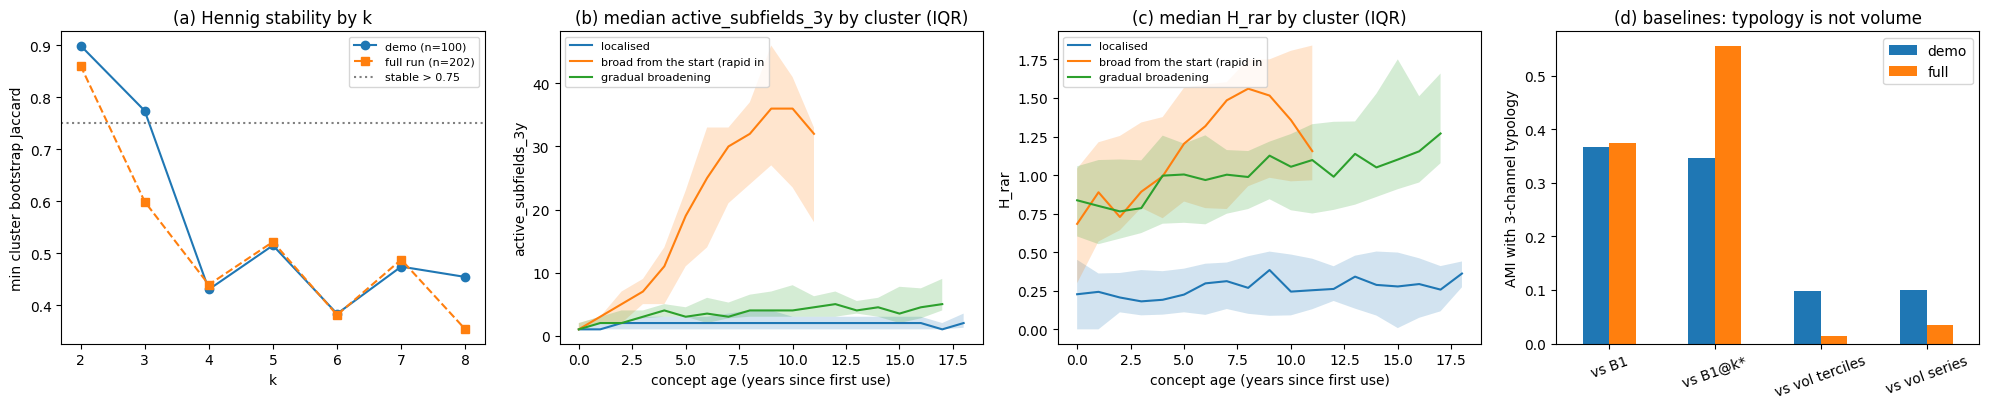

In [17]:
ref = data["full_run_reference"]
by_k = pd.DataFrame({int(kk): dict(min_jaccard=v["min_jaccard"], silhouette=v["silhouette"], sizes=v["sizes"],
                                   band=v["hennig_band_min"]) for kk, v in out["by_k"].items()}).T
by_k["full_run_min_jaccard (n=202)"] = [ref["min_jaccard_by_k"].get(str(kk)) for kk in by_k.index]
print(f"=== 3-channel typology on {len(ids)} concepts: status={out['status']}, k*={k} (full run: k*={ref['k_selected']}, {ref['status']})")
print(by_k.to_string())

print("\n=== cluster names / sizes (demo)  vs  full run sizes", ref["cluster_sizes"], ref["cluster_names"])
print(asg.cluster_name.value_counts().to_string())

agree = pd.crosstab(asg.cluster_name.rename("demo"), asg.concept_id.map(pinfo.full_run_cluster_name).rename("full run"))
print("\n=== demo label vs full-run label on the same concepts\n", agree.to_string())
print(f"AMI(demo, full run) = {ami(asg.set_index('concept_id').cluster_name, pinfo.full_run_cluster_name):.3f}")

print("\n=== baselines (demo vs full run)")
print(pd.DataFrame(dict(demo=pd.Series(out["baselines"]), full_run=pd.Series(ref["baselines"]))).round(3).to_string())
print(f"B1 entropy-only free k: demo k={b1['k']} min J={b1['min_jaccard']:.3f} | full run k={ref['B1_entropy_only_MAIN']['k']} "
      f"min J={ref['B1_entropy_only_MAIN']['min_jaccard']:.3f}")
print("volume-driven flag:", out["volume_driven_flag"]["flag"])

fig, ax = plt.subplots(1, 4, figsize=(20, 4.2))
ks = sorted(by_k.index)
ax[0].plot(ks, by_k.loc[ks, "min_jaccard"].astype(float), "o-", label=f"demo (n={len(ids)})")
ax[0].plot(ks, [ref["min_jaccard_by_k"].get(str(kk)) for kk in ks], "s--", label="full run (n=202)")
ax[0].axhline(JAC_MIN, color="grey", ls=":", label="stable > 0.75")
ax[0].set(xlabel="k", ylabel="min cluster bootstrap Jaccard", title="(a) Hennig stability by k"); ax[0].legend(fontsize=8)
for j, ch in enumerate(["active_subfields_3y", "H_rar"]):
    for cl, g in traj.groupby("cluster"):
        g = g[g.n >= 5]
        ax[1 + j].plot(g.age, g[f"{ch}_0.5"], label=names[cl][:30])
        ax[1 + j].fill_between(g.age, g[f"{ch}_0.25"], g[f"{ch}_0.75"], alpha=0.2)
    ax[1 + j].set(xlabel="concept age (years since first use)", ylabel=ch, title=f"({'bc'[j]}) median {ch} by cluster (IQR)")
    ax[1 + j].legend(fontsize=8)
bl = pd.DataFrame(dict(demo=pd.Series(out["baselines"]), full=pd.Series(ref["baselines"]))).loc[
    ["AMI_3ch_vs_B1", "AMI_3ch_vs_B1_kstar", "AMI_3ch_vs_B2_tercile", "AMI_3ch_vs_B2_volseries"]]
bl.index = ["vs B1", "vs B1@k*", "vs vol terciles", "vs vol series"]
bl.plot.bar(ax=ax[3], rot=20)
ax[3].set(ylabel="AMI with 3-channel typology", title="(d) baselines: typology is not volume")
plt.tight_layout(); plt.show()